# Day 1 | Lab 1.4: Transformer Architecture & Tokenization Fundamentals

**Duration:** ~1.5 hours

**Scenario.** Mixed banking, e-commerce, healthcare, regulatory examples — preserved from source. The lab is concept-led (architecture families, tokenization, attention) rather than scenario-led; sample data is a vehicle for the technical points.

**Learning Objectives.** By the end of this lab, you will be able to:
1. Compare tokenization across model families (BPE, WordPiece, SentencePiece) and estimate prompt token budgets.
2. Explain context-window mechanics and their downstream impact on chunking and cost.
3. Use **Encoder-Only** models (BERT) for classification and token-level NER.
4. Use **Decoder-Only** models (GPT, Llama) for autoregressive text generation via API.
5. Use **Encoder-Decoder** models (FLAN-T5) for sequence-to-sequence tasks (summarization, Q&A).
6. Read attention heatmaps to understand what a transformer is focusing on (interpretability).
7. Apply an architecture-selection framework to real business scenarios (volume, latency, cost).

**Architecture families covered**

| Architecture | Example Model | Strength | Typical Use Case |
|---|---|---|---|
| Encoder-Only | BERT | Bidirectional understanding | Classification, NER, embeddings |
| Decoder-Only | GPT (OpenAI / Groq-Llama) | Autoregressive generation | Generation, chatbots, code |
| Encoder-Decoder | T5 / FLAN-T5 | Sequence-to-sequence | Summarization, translation, Q&A |

---


## 1. Install Dependencies

In [ ]:
# Required packages for this lab — already installed in your local venv.
# To install standalone, uncomment the line(s) below:
# !pip install openai groq transformers torch sentencepiece protobuf tiktoken matplotlib seaborn pandas -q
!pip install transformers torch sentencepiece protobuf tiktoken tqdm -q


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. API Key Configuration

In [1]:
import os

# Local-venv pattern: load from .env if python-dotenv is available, otherwise rely on
# environment variables already set in your shell or venv activation script.
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# Verify keys are loaded (prints status, never prints actual values)
for key in ['OPENAI_API_KEY', 'GROQ_API_KEY']:
    status = '✅ Loaded' if os.environ.get(key) else '❌ MISSING'
    print(f'{key}: {status}')


OPENAI_API_KEY: ✅ Loaded
GROQ_API_KEY: ✅ Loaded


## 3. Initialize API Clients

In [3]:
from openai import OpenAI
from groq import Groq

openai_client = OpenAI()
groq_client = Groq()

print("API clients initialized ✅")

API clients initialized ✅


---

## 4. Tokenization Deep-Dive: How Different Models See Text

### Business Scenario: Token Budget Planning for a Banking Chatbot
A retail bank is building a customer-support chatbot. The engineering team must estimate token costs for different message types (short queries vs. long policy documents). Understanding how tokenizers break text differently is critical for **cost estimation, context window management, and prompt design**.

We compare tokenization across three tokenizer families:
- **tiktoken** (GPT-4.1 / GPT-5 family — BPE tokenizer)
- **BERT WordPiece** (encoder-only models)
- **T5 SentencePiece** (encoder-decoder models)

In [6]:
import tiktoken
from transformers import AutoTokenizer

# Load tokenizers for each architecture family
gpt_tokenizer = tiktoken.encoding_for_model("gpt-4o")            # BPE — used by GPT-4.1/5 family
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")  # WordPiece — encoder-only
t5_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")  # SentencePiece — encoder-decoder

print("Tokenizers loaded ✅")

Tokenizers loaded ✅


In [7]:
import pandas as pd

# Sample texts from banking domain — varying complexity
sample_texts = {
    "Short query": "What is my account balance?",
    "Medium query": "I need to dispute a transaction of ₹15,750 charged on 12/Jan/2025 by Amazon.in on my HDFC credit card ending 4832.",
    "Policy excerpt": """The Reserve Bank of India (RBI) mandates that all scheduled commercial banks maintain
a Cash Reserve Ratio (CRR) of 4.50% of their Net Demand and Time Liabilities (NDTL).
Non-compliance attracts a penalty of 3% above the bank rate for the first default and
5% above the bank rate for subsequent defaults within the same reporting fortnight.""",
    "Technical jargon": "The LSTM-based encoder-decoder with Bahdanau attention achieved 94.3% F1 on NER for SWIFT MT103 messages.",
}

def compare_tokenizers(text, label):
    """Tokenize with all three tokenizers and return a comparison row."""
    gpt_tokens = gpt_tokenizer.encode(text)
    bert_tokens = bert_tokenizer.tokenize(text)
    t5_tokens = t5_tokenizer.tokenize(text)
    return {
        "Text": label,
        "Chars": len(text),
        "GPT (BPE)": len(gpt_tokens),
        "BERT (WordPiece)": len(bert_tokens),
        "T5 (SentencePiece)": len(t5_tokens),
    }

rows = [compare_tokenizers(text, label) for label, text in sample_texts.items()]
df = pd.DataFrame(rows)
display(df)

,Text,Chars,GPT (BPE),BERT (WordPiece),T5 (SentencePiece)
0,Short query,27,6,6,6
1,Medium query,114,34,33,35
2,Policy excerpt,340,79,77,85
3,Technical jargon,105,30,34,37


In [8]:
# Visualize how each tokenizer splits the same sentence
demo_text = "The HDFC Bank's Q3 net profit rose 18.5% to ₹16,372 crore year-on-year."

print(f"Original: {demo_text}\n")
print(f"GPT (BPE) tokens:       {gpt_tokenizer.encode(demo_text)}")
# Decode individual tokens to see the splits
print(f"  → pieces: {[gpt_tokenizer.decode([t]) for t in gpt_tokenizer.encode(demo_text)]}\n")

print(f"BERT (WordPiece) tokens: {bert_tokenizer.tokenize(demo_text)}\n")
print(f"T5 (SentencePiece) tokens: {t5_tokenizer.tokenize(demo_text)}")

Original: The HDFC Bank's Q3 net profit rose 18.5% to ₹16,372 crore year-on-year.

GPT (BPE) tokens:       [976, 487, 142726, 9950, 885, 1486, 18, 2776, 15971, 23103, 220, 1157, 13, 20, 4, 316, 73406, 1125, 11, 34036, 84459, 1284, 13237, 8204, 13]
  → pieces: ['The', ' H', 'DFC', ' Bank', "'s", ' Q', '3', ' net', ' profit', ' rose', ' ', '18', '.', '5', '%', ' to', ' ₹', '16', ',', '372', ' crore', ' year', '-on', '-year', '.']

BERT (WordPiece) tokens: ['the', 'hd', '##fc', 'bank', "'", 's', 'q', '##3', 'net', 'profit', 'rose', '18', '.', '5', '%', 'to', '₹', '##16', ',', '37', '##2', 'crore', 'year', '-', 'on', '-', 'year', '.']

T5 (SentencePiece) tokens: ['▁The', '▁HD', 'FC', '▁Bank', "'", 's', '▁Q', '3', '▁net', '▁profit', '▁rose', '▁18.', '5%', '▁to', '▁', '₹', '16', ',', '37', '2', '▁crore', '▁year', '-', 'on', '-', 'year', '.']


### 📝 Key Observations
- **BPE (GPT)** is efficient on common English words, but splits rare words and non-Latin scripts into many tokens
- **WordPiece (BERT)** uses `##` prefix to denote sub-word continuations
- **SentencePiece (T5)** uses `▁` to mark word boundaries — it's language-agnostic
- Token counts vary significantly across tokenizers — **always estimate tokens with the specific model's tokenizer** before budgeting

---

## 5. Context Window Mechanics: Token Budgets & Truncation

### Business Scenario: Processing Long Insurance Policy Documents
An insurance company wants to use an LLM to answer questions about their 80-page policy documents. The engineering team needs to understand **context window limits** and plan a chunking strategy.

Context window = max tokens the model can process in one request (input + output combined).

| Model | Context Window | ~Pages of Text |
|---|---|---|
| BERT-base | 512 tokens | ~1 page |
| GPT-4.1-mini | 1,000,000 tokens | ~1,500 pages |
| GPT-5-mini | 400,000 tokens | ~600 pages |
| Llama 3.3 70B | 128,000 tokens | ~200 pages |
| FLAN-T5-base | 512 tokens | ~1 page |

In [9]:
def estimate_token_budget(text, model_context_window, tokenizer_fn):
    """
    Estimate whether a text fits within a model's context window.
    Returns token count and the percentage of the context window used.
    """
    token_count = len(tokenizer_fn(text))
    pct_used = round((token_count / model_context_window) * 100, 2)
    fits = "✅ Fits" if token_count < model_context_window else "❌ Exceeds"
    return {"tokens": token_count, "pct_used": pct_used, "status": fits}

# Simulate a long insurance policy (repeat a paragraph to simulate a long doc)
policy_paragraph = """This policy covers the insured individual against hospitalization expenses
arising from illness or accidental injury, subject to the terms, conditions, and exclusions
mentioned herein. The sum insured is applicable per policy year on a floater basis for all
insured members. Pre-existing conditions are covered after a continuous waiting period of
48 months from the date of inception of the first policy. """

# Create documents of different lengths
doc_sizes = {"1 page (~500 words)": 3, "10 pages (~1500 words)": 30, "50 pages (~75000 words)": 150}

print("Token budget estimation for insurance policy document:\n")
for label, repeats in doc_sizes.items():
    long_text = policy_paragraph * repeats
    gpt_result = estimate_token_budget(long_text, 1_000_000, gpt_tokenizer.encode)   # GPT-4.1-mini
    bert_result = estimate_token_budget(long_text, 512, bert_tokenizer.tokenize)      # BERT-base
    print(f"📄 {label}:")
    print(f"   GPT-4.1-mini (1M ctx): {gpt_result['tokens']} tokens ({gpt_result['pct_used']}%) → {gpt_result['status']}")
    print(f"   BERT-base (512 ctx):    {bert_result['tokens']} tokens ({bert_result['pct_used']}%) → {bert_result['status']}")
    print()

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2280 > 512). Running this sequence through the model will result in indexing errors


Token budget estimation for insurance policy document:

📄 1 page (~500 words):
   GPT-4.1-mini (1M ctx): 223 tokens (0.02%) → ✅ Fits
   BERT-base (512 ctx):    228 tokens (44.53%) → ✅ Fits

📄 10 pages (~1500 words):
   GPT-4.1-mini (1M ctx): 2221 tokens (0.22%) → ✅ Fits
   BERT-base (512 ctx):    2280 tokens (445.31%) → ❌ Exceeds

📄 50 pages (~75000 words):
   GPT-4.1-mini (1M ctx): 11101 tokens (1.11%) → ✅ Fits
   BERT-base (512 ctx):    11400 tokens (2226.56%) → ❌ Exceeds



In [10]:
# Demonstrate safe truncation — essential for BERT-based pipelines
def safe_truncate(text, tokenizer, max_tokens=512):
    """Truncate text to fit within max_tokens using the given tokenizer."""
    tokens = tokenizer.encode(text, add_special_tokens=False)
    if len(tokens) <= max_tokens:
        return text, len(tokens)
    truncated_tokens = tokens[:max_tokens]
    truncated_text = tokenizer.decode(truncated_tokens)
    return truncated_text, max_tokens

long_doc = policy_paragraph * 30   # ~10 pages
truncated, tok_count = safe_truncate(long_doc, bert_tokenizer, max_tokens=512)
print(f"Original doc: {len(bert_tokenizer.encode(long_doc, add_special_tokens=False))} BERT tokens")
print(f"After truncation to 512: {tok_count} tokens")
print(f"Truncated preview: {truncated[:200]}...")

Original doc: 2280 BERT tokens
After truncation to 512: 512 tokens
Truncated preview: this policy covers the insured individual against hospitalization expenses arising from illness or accidental injury, subject to the terms, conditions, and exclusions mentioned herein. the sum insured...


### 📝 Key Takeaways
- **Encoder-only models (BERT)** have small context windows (512 tokens) — you MUST chunk long documents
- **Decoder-only models (GPT-4.1-mini, GPT-5-mini)** have massive context windows (400K–1M tokens) — can handle entire documents
- **Token cost is real** — every token in the context window costs money with API-based models
- In production: always implement **safe truncation** or **chunking** as a guard against exceeding context limits

---

## 6. Architecture 1 — Encoder-Only (BERT): Classification & NER

### Business Scenario: Automated Customer Complaint Triage
A bank receives thousands of customer complaints daily. They need to:
1. **Classify** the sentiment of each complaint (positive/negative/neutral)
2. **Extract** named entities (product names, monetary amounts, dates) from complaint text

Encoder-only models like BERT excel at these **understanding** tasks because they read the entire input bidirectionally — every token attends to every other token in both directions.

**Architecture Insight:** BERT uses only the **encoder** stack of the original Transformer. The output is a rich contextual representation of each input token, which can be used for classification (via `[CLS]` token) or token-level tasks (NER).

In [11]:
from transformers import pipeline

# Load pre-trained sentiment analysis pipeline (uses a fine-tuned BERT variant)
sentiment_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Banking customer complaints
complaints = [
    "I've been charged ₹2,500 for a transaction I never authorized. This is unacceptable!",
    "The new mobile banking app is really smooth and easy to use. Great upgrade!",
    "My fixed deposit matured last week but the amount hasn't been credited to my savings account yet.",
    "Your customer service team resolved my issue within 10 minutes. Very impressed.",
    "I've been waiting 3 weeks for my replacement debit card. Still nothing.",
]

print("🏦 Sentiment Classification (Encoder-Only: DistilBERT)\n")
for text in complaints:
    result = sentiment_pipe(text)[0]
    emoji = "😊" if result["label"] == "POSITIVE" else "😠"
    print(f"  {emoji} [{result['label']:>8s}] (conf: {result['score']:.3f}) → {text[:80]}...")

c:\venvs\eclerx-genai\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\prash\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1603.55it/s]


🏦 Sentiment Classification (Encoder-Only: DistilBERT)

  😠 [NEGATIVE] (conf: 1.000) → I've been charged ₹2,500 for a transaction I never authorized. This is unaccepta...
  😊 [POSITIVE] (conf: 1.000) → The new mobile banking app is really smooth and easy to use. Great upgrade!...
  😠 [NEGATIVE] (conf: 0.995) → My fixed deposit matured last week but the amount hasn't been credited to my sav...
  😊 [POSITIVE] (conf: 1.000) → Your customer service team resolved my issue within 10 minutes. Very impressed....
  😠 [NEGATIVE] (conf: 1.000) → I've been waiting 3 weeks for my replacement debit card. Still nothing....


In [13]:
# Named Entity Recognition — token-level classification (another encoder-only strength)
ner_pipe = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")

ner_texts = [
    "Mr. Rajesh Sharma filed a complaint against HDFC Bank for unauthorized debit of INR 50,000 on 15th January 2025.",
    "The Reserve Bank of India issued new guidelines for ICICI Bank and State Bank of India regarding digital lending.",
]

print("🏷️ Named Entity Recognition (Encoder-Only: BERT-NER)\n")
for text in ner_texts:
    print(f"  Text: {text}")
    entities = ner_pipe(text)
    for ent in entities:
        print(f"    → [{ent['entity_group']:>5s}] {ent['word']:25s} (conf: {ent['score']:.3f})")
    print()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7524.94it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🏷️ Named Entity Recognition (Encoder-Only: BERT-NER)

  Text: Mr. Rajesh Sharma filed a complaint against HDFC Bank for unauthorized debit of INR 50,000 on 15th January 2025.
    → [  PER] Rajesh Sharma             (conf: 0.913)
    → [  ORG] HDFC Bank                 (conf: 0.999)
    → [ MISC] IN                        (conf: 0.863)

  Text: The Reserve Bank of India issued new guidelines for ICICI Bank and State Bank of India regarding digital lending.
    → [  ORG] Reserve Bank of India     (conf: 0.999)
    → [  ORG] ICICI Bank                (conf: 0.990)
    → [  ORG] State Bank of India       (conf: 0.999)



### 📝 Why Encoder-Only Excels Here
- **Bidirectional attention**: To classify "*I never authorized*" correctly, BERT reads both left ("I've been charged") and right ("This is unacceptable") — full context in both directions
- **Token-level outputs**: Each token gets its own representation, enabling fine-grained NER
- **Fast inference**: No autoregressive generation loop — single forward pass
- **Limitation**: Cannot *generate* new text — only classify, extract, or score existing text

---

## 7. Architecture 2 — Decoder-Only (GPT / Llama): Text Generation

### Business Scenario: AI-Powered Customer Response Drafting
A wealth management firm wants to auto-draft personalized responses to client queries. The model must **generate** coherent, contextual replies — this is where decoder-only models shine.

**Architecture Insight:** Decoder-only models (GPT, Llama) use **causal (masked) self-attention** — each token can only attend to tokens *before* it (left-to-right). This makes them natural text generators: they predict the next token, one at a time.

We use two decoder-only models:
- **GPT-4.1-mini** (OpenAI) — proprietary, non-reasoning, supports temperature
- **Llama 3.3 70B** (via Groq Cloud) — open-source, fast inference on Groq LPU hardware

In [14]:
import time

def generate_openai(prompt, instructions="", temperature=0.7, model="gpt-4.1-mini"):
    """Generate text using OpenAI Responses API (decoder-only architecture)."""
    start = time.time()
    response = openai_client.responses.create(
        model=model,
        instructions=instructions,
        input=prompt,
        temperature=temperature,
    )
    latency = round(time.time() - start, 2)
    return {"text": response.output_text, "latency": latency, "model": model}


def generate_groq(prompt, system_prompt="", temperature=0.7, model="llama-3.3-70b-versatile"):
    """Generate text using Groq Cloud (Llama — decoder-only, open-source)."""
    start = time.time()
    response = groq_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt}
        ],
        temperature=temperature
    )
    latency = round(time.time() - start, 2)
    return {"text": response.choices[0].message.content, "latency": latency, "model": model}

print("Generator functions defined ✅")

Generator functions defined ✅


In [15]:
# --- Decoder-only generation: auto-draft client responses ---
instructions = """You are a senior wealth advisor at a private bank. Draft a brief, professional
response to the client's query. Be empathetic, specific, and limit your response to 3-4 sentences."""

client_query = """I'm concerned about the recent market volatility. My portfolio is heavily
invested in mid-cap equity funds and I'm seeing a 12% decline this quarter.
Should I rebalance or hold steady?"""

print("🤖 GPT-4.1-mini (OpenAI — Decoder-Only):")
gpt_result = generate_openai(client_query, instructions=instructions, temperature=0.7)
print(f"   [{gpt_result['latency']}s] {gpt_result['text']}\n")

print("🤖 Llama 3.3 70B (Groq — Decoder-Only):")
llama_result = generate_groq(client_query, system_prompt=instructions, temperature=0.7)
print(f"   [{llama_result['latency']}s] {llama_result['text']}")

🤖 GPT-4.1-mini (OpenAI — Decoder-Only):
   [3.96s] Thank you for sharing your concerns. Given the recent volatility and your significant exposure to mid-cap equities, it may be prudent to review your portfolio’s overall risk tolerance and investment goals before making any decisions. A balanced approach, possibly involving some rebalancing to diversify, can help mitigate risk while positioning you for future growth. I’m happy to schedule a detailed review to tailor a strategy suited to your needs.

🤖 Llama 3.3 70B (Groq — Decoder-Only):
   [0.51s] I completely understand your concerns regarding the recent market volatility and its impact on your portfolio. Given the 12% decline in your mid-cap equity funds, I recommend reviewing your asset allocation to determine if rebalancing is necessary to ensure it remains aligned with your investment objectives and risk tolerance. Holding steady may be a viable option if your long-term strategy remains intact, but rebalancing could help mitigate 

In [16]:
# --- Demonstrate causal (autoregressive) nature: the model generates left-to-right ---
# We show how the same prompt prefix leads to different completions at different temperatures

prefix = "The three most important factors when evaluating a mutual fund are"

print("🌡️ Temperature effect on decoder-only generation (GPT-4.1-mini):\n")
for k in range(5):
  for temp in [0.0, 0.5, 1.2]:
      result = generate_openai(
          prefix,
          instructions="Complete the sentence in exactly one sentence. Be specific.",
          temperature=temp
      )
      print(f"  temp={temp:.1f} → {result['text']}")
      print()
  print("="*60)

🌡️ Temperature effect on decoder-only generation (GPT-4.1-mini):

  temp=0.0 → The three most important factors when evaluating a mutual fund are its historical performance relative to its benchmark, the fund manager's experience and track record, and the expense ratio or fees associated with the fund.

  temp=0.5 → The three most important factors when evaluating a mutual fund are its historical performance relative to benchmarks, the fund manager’s experience and track record, and the expense ratio or fees associated with the fund.

  temp=1.2 → The three most important factors when evaluating a mutual fund are its historical performance, fees and expense ratios, and the experience and track record of the fund manager.

  temp=0.0 → The three most important factors when evaluating a mutual fund are its historical performance relative to its benchmark, the fund manager’s experience and track record, and the expense ratio or fees associated with the fund.

  temp=0.5 → The three most i

### 📝 Why Decoder-Only Excels at Generation
- **Causal attention mask**: Each token only sees previous tokens → naturally generates the next word
- **Scales well**: GPT-5, Llama 3 — the largest and most capable models are all decoder-only
- **Flexible**: Can do generation, summarization, Q&A, code, and more via prompting
- **Trade-off**: Unidirectional attention means less rich *understanding* of input compared to bidirectional BERT (for classification tasks, a fine-tuned BERT is often better than prompting a GPT)

---

## 8. Architecture 3 — Encoder-Decoder (T5 / FLAN-T5): Sequence-to-Sequence

### Business Scenario: Automated Summarization of Regulatory Filings
A compliance team at a bank needs to summarize lengthy RBI circulars and regulatory filings into concise bullet points. Encoder-decoder models are purpose-built for these **input→output transformation** tasks.

**Architecture Insight:** Encoder-Decoder models (T5, BART) have two transformer stacks:
1. **Encoder** — reads the full input with bidirectional attention (like BERT)
2. **Decoder** — generates the output autoregressively, attending to the encoder's representations via **cross-attention**

This combination gives the best of both worlds: deep input understanding + generative output.

In [17]:
# Load FLAN-T5 — using the 'text-generation' task as per environment availability
summarizer = pipeline("text-generation", model="google/flan-t5-base", max_new_tokens=150)

# A regulatory text that needs summarization
regulatory_text = """
The Reserve Bank of India has introduced the Unified Lending Interface (ULI) framework
to streamline credit assessment and delivery. ULI enables consent-based digital access
to borrower information from multiple sources including land records, satellite data,
and financial statements. The framework aims to reduce the cost of credit assessment,
particularly for rural and small borrowers who lack traditional credit histories.
Banks and NBFCs can integrate with ULI through standardized APIs. The pilot phase
covers agricultural lending in select districts of Maharashtra and Karnataka.
The RBI expects ULI to reduce loan processing time from weeks to days and lower
the rejection rate for first-time borrowers by approximately 30 percent.
"""

print(" Original text:", len(regulatory_text.split()), "words\n")

# T5 expects a task prefix like 'summarize: '
input_text = f"summarize: {regulatory_text}"
summary = summarizer(input_text)

# Accessing the generated text key
print(f"Summary: {summary[0]['generated_text']}")

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 4116.77it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM'

 Original text: 107 words



[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Summary: summarize: 
The Reserve Bank of India has introduced the Unified Lending Interface (ULI) framework
to streamline credit assessment and delivery. ULI enables consent-based digital access
to borrower information from multiple sources including land records, satellite data,
and financial statements. The framework aims to reduce the cost of credit assessment,
particularly for rural and small borrowers who lack traditional credit histories.
Banks and NBFCs can integrate with ULI through standardized APIs. The pilot phase
covers agricultural lending in select districts of Maharashtra and Karnataka.
The RBI expects ULI to reduce loan processing time from weeks to days and lower
the rejection rate for first-time borrowers by approximately 30 percent.



In [18]:
# Updated to 'text-generation' to match available pipeline tasks
t5_text2text = pipeline("text-generation", model="google/flan-t5-base", max_new_tokens=200)

# Task 1: Extractive Q&A over a banking context
qa_input = """Answer the question based on the context.
Context: HDFC Bank reported a net profit of ₹16,372 crore for Q3 FY2025,
a growth of 18.5% year-on-year. Net interest income stood at ₹30,650 crore.
The bank's gross NPA ratio improved to 1.24% from 1.36% in the previous quarter.
Question: What was HDFC Bank's net profit in Q3 FY2025?"""

print("❓ Q&A Task (Encoder-Decoder: FLAN-T5)")
result = t5_text2text(qa_input)
print(f"   Answer: {result[0]['generated_text']}\n")

# Task 2: Paraphrase / rephrase
paraphrase_input = "Paraphrase: The bank's non-performing assets declined significantly in the reporting quarter."
print("Paraphrase Task (Encoder-Decoder: FLAN-T5)")
result = t5_text2text(paraphrase_input)
print(f"   Output: {result[0]['generated_text']}\n")

# Task 3: Sentiment (using T5's text-to-text framing)
sentiment_input = "Classify the sentiment: I am extremely disappointed with the loan processing delays at this bank."
print("Sentiment via Text-to-Text (Encoder-Decoder: FLAN-T5)")
result = t5_text2text(sentiment_input)
print(f"   Output: {result[0]['generated_text']}")

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 7008.77it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', '

❓ Q&A Task (Encoder-Decoder: FLAN-T5)


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Answer: Answer the question based on the context.
Context: HDFC Bank reported a net profit of ₹16,372 crore for Q3 FY2025,
a growth of 18.5% year-on-year. Net interest income stood at ₹30,650 crore.
The bank's gross NPA ratio improved to 1.24% from 1.36% in the previous quarter.
Question: What was HDFC Bank's net profit in Q3 FY2025?

Paraphrase Task (Encoder-Decoder: FLAN-T5)


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Output: Paraphrase: The bank's non-performing assets declined significantly in the reporting quarter.

Sentiment via Text-to-Text (Encoder-Decoder: FLAN-T5)
   Output: Classify the sentiment: I am extremely disappointed with the loan processing delays at this bank.


### 📝 Why Encoder-Decoder Works Well for Seq-to-Seq
- **Cross-attention**: The decoder attends to encoder representations — best for tasks where output depends heavily on specific parts of the input
- **Structured task framing**: T5's "text-to-text" paradigm handles summarization, translation, Q&A, and classification all through the same interface
- **Limitation**: Smaller models (T5-base) have limited generation quality compared to large decoder-only models. In production, decoder-only models (GPT/Llama) often outperform small encoder-decoder models for generation tasks due to sheer scale

---

## 9. Visualizing Self-Attention: How Transformers Focus

### Business Scenario: Debugging Model Behavior
When an NLP model makes a wrong prediction (e.g., misclassifies a complaint), understanding *what the model attended to* helps debug the issue. Attention heatmaps are a practical interpretability tool.

We extract and visualize attention weights from BERT to see how the model "focuses" when reading a banking sentence.

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7664.73it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


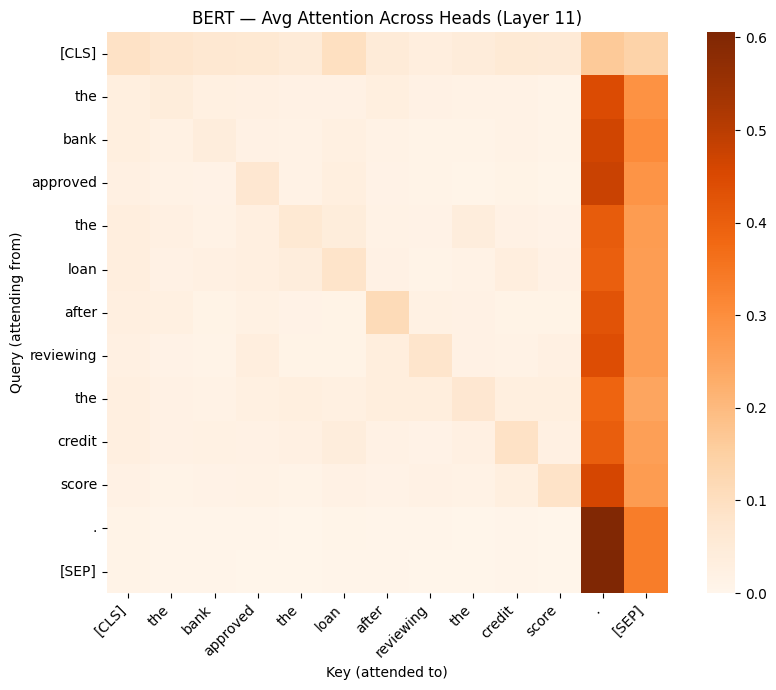

In [19]:
# --- Self-attention visualization (combined, simplified) ---
# This is a single-cell summary: load BERT, run a forward pass with attentions,
# and plot the per-layer *average across heads* — enough to read the heatmap.
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertModel, BertTokenizer

bert_model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
bert_tok = BertTokenizer.from_pretrained('bert-base-uncased')

text = 'The bank approved the loan after reviewing the credit score.'
inputs = bert_tok(text, return_tensors='pt')
tokens = bert_tok.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    out = bert_model(**inputs)
attentions = out.attentions  # tuple of (batch, heads, seq, seq) per layer

# Plot the average attention across all heads in the LAST layer (semantic-rich)
layer = 11
attn = attentions[layer][0].mean(dim=0).numpy()  # (seq, seq), averaged across heads

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap='Oranges', vmin=0, square=True, ax=ax)
ax.set_title(f'BERT — Avg Attention Across Heads (Layer {layer})')
ax.set_xlabel('Key (attended to)')
ax.set_ylabel('Query (attending from)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 📝 Reading the Attention Heatmaps
- Each cell (row *i*, col *j*) shows how much token *i* attends to token *j*
- **Bright cells** = strong attention; **dark cells** = weak attention
- **[CLS] token** often attends broadly (it aggregates information for classification)
- **Early layers**: tend to capture local, syntactic relationships (adjacent words)
- **Later layers**: tend to capture semantic relationships ("bank" ↔ "loan" ↔ "credit")
- **Multi-head attention** allows different heads to learn different patterns simultaneously — averaging across heads gives the composite view

---

## 10. Architecture Comparison: Same Task, Three Approaches

### Business Scenario: E-Commerce Product Review Analysis
An e-commerce platform wants to analyze customer reviews to extract sentiment. We compare how each architecture handles this task:

| Approach | Architecture | Method |
|---|---|---|
| BERT (encoder-only) | Fine-tuned classifier | Single forward pass, returns label |
| GPT-4.1-mini (decoder-only) | Prompted via API | Generates text response |
| FLAN-T5 (encoder-decoder) | Text-to-text | Generates label as text |

In [20]:
# Product reviews for comparison
reviews = [
    "This laptop is blazing fast and the battery lasts all day. Best purchase I've made!",
    "The delivery was delayed by 2 weeks and the product arrived with a cracked screen.",
    "Decent phone for the price. Camera is okay but the battery could be better.",
]

# --- Approach 1: BERT (encoder-only) — fine-tuned classifier ---
print("🔵 BERT (Encoder-Only) — Fine-Tuned Sentiment Classifier")
for review in reviews:
    result = sentiment_pipe(review)[0]
    print(f"   [{result['label']:>8s}] (conf: {result['score']:.3f}) → {review[:70]}...")
print()

🔵 BERT (Encoder-Only) — Fine-Tuned Sentiment Classifier
   [POSITIVE] (conf: 0.916) → This laptop is blazing fast and the battery lasts all day. Best purcha...
   [NEGATIVE] (conf: 1.000) → The delivery was delayed by 2 weeks and the product arrived with a cra...
   [NEGATIVE] (conf: 0.937) → Decent phone for the price. Camera is okay but the battery could be be...



In [21]:
# --- Approach 2: GPT-4.1-mini (decoder-only) — prompted via API ---
print("🟢 GPT-4.1-mini (Decoder-Only) — Prompted Sentiment Analysis")
for review in reviews:
    result = generate_openai(
        prompt=f"Classify the sentiment of this product review as POSITIVE, NEGATIVE, or NEUTRAL. Reply with just the label.\n\nReview: {review}",
        instructions="You are a sentiment classifier. Respond with exactly one word: POSITIVE, NEGATIVE, or NEUTRAL.",
        temperature=0.0
    )
    print(f"   [{result['text'].strip():>8s}] ({result['latency']}s) → {review[:70]}...")
print()

🟢 GPT-4.1-mini (Decoder-Only) — Prompted Sentiment Analysis
   [POSITIVE] (1.12s) → This laptop is blazing fast and the battery lasts all day. Best purcha...
   [NEGATIVE] (1.09s) → The delivery was delayed by 2 weeks and the product arrived with a cra...
   [ NEUTRAL] (1.11s) → Decent phone for the price. Camera is okay but the battery could be be...



In [22]:
# --- Approach 3: FLAN-T5 (encoder-decoder) — text-to-text ---
print("🟡 FLAN-T5 (Encoder-Decoder) — Text-to-Text Sentiment")
for review in reviews:
    input_text = f"Classify the sentiment of this review as positive, negative, or neutral: {review}"
    result = t5_text2text(input_text, max_length=10)
    print(f"   [{result[0]['generated_text']:>8s}] → {review[:70]}...")
print()

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=200) and `max_length`(=10) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=10) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🟡 FLAN-T5 (Encoder-Decoder) — Text-to-Text Sentiment
   [Classify the sentiment of this review as positive, negative, or neutral: This laptop is blazing fast and the battery lasts all day. Best purchase I've made!] → This laptop is blazing fast and the battery lasts all day. Best purcha...
   [Classify the sentiment of this review as positive, negative, or neutral: The delivery was delayed by 2 weeks and the product arrived with a cracked screen.] → The delivery was delayed by 2 weeks and the product arrived with a cra...


[transformers] Both `max_new_tokens` (=200) and `max_length`(=10) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   [Classify the sentiment of this review as positive, negative, or neutral: Decent phone for the price. Camera is okay but the battery could be better.] → Decent phone for the price. Camera is okay but the battery could be be...



### 📝 Comparison Notes
- **BERT**: Fastest inference, highest confidence, but requires fine-tuning for each new task
- **GPT-4.1-mini**: Most flexible (just change the prompt), but higher latency and cost per classification
- **FLAN-T5**: Good middle ground — follows instructions without fine-tuning, runs locally, but smaller model = lower accuracy on edge cases
- **Production insight**: For high-volume classification (millions of reviews), fine-tuned BERT is most cost-effective. For flexible, low-volume tasks, prompted GPT is easiest to deploy.

---

## 11. Architecture Selection Exercise

### Framework: Choosing the Right Architecture

This is the core hands-on exercise for Module 5. For each real-world scenario below, choose the most appropriate transformer architecture and justify your decision.

**Decision Framework:**

```
Does the task require GENERATING new text?
├── YES → Is the output a transformation of the input (summary, translation)?
│          ├── YES → Encoder-Decoder (T5, BART) or large Decoder-Only (GPT)
│          └── NO (open-ended generation) → Decoder-Only (GPT, Llama)
└── NO (understanding/classification only)
           → Encoder-Only (BERT, RoBERTa)
```

**Additional factors:** latency requirements, cost, data volume, need for fine-tuning, context length.

In [23]:
# Architecture Selection Exercise — 8 real-world scenarios across industries
scenarios = [
    {
        "id": 1,
        "domain": "Banking",
        "task": "Classify 500,000 daily transactions as potentially fraudulent or legitimate",
        "constraints": "Latency < 50ms per transaction, runs on internal GPU cluster",
        "recommended": "Encoder-Only (BERT / RoBERTa)",
        "reasoning": "Binary classification at high volume with strict latency — fine-tuned encoder model gives single-pass inference. No text generation needed."
    },
    {
        "id": 2,
        "domain": "Insurance",
        "task": "Auto-generate claim denial/approval letters based on policy terms and claim details",
        "constraints": "Must reference specific policy clauses, personalized per claimant",
        "recommended": "Decoder-Only (GPT-5-mini / GPT-4.1-mini)",
        "reasoning": "Open-ended text generation with context injection (policy + claim data). Decoder-only excels at fluent, contextual generation from prompts."
    },
    {
        "id": 3,
        "domain": "Healthcare",
        "task": "Summarize doctor's clinical notes (2-3 pages) into a 5-line discharge summary",
        "constraints": "Must preserve medical accuracy, runs locally in hospital network (no cloud API)",
        "recommended": "Encoder-Decoder (FLAN-T5 / BART) or fine-tuned local decoder model",
        "reasoning": "Summarization is a seq-to-seq task. Encoder-decoder reads full input bidirectionally, then generates concise output. Runs locally without API dependency."
    },
    {
        "id": 4,
        "domain": "E-Commerce",
        "task": "Extract product attributes (brand, size, color, material) from 10M unstructured product listings",
        "constraints": "Batch processing, cost-efficient, high accuracy on structured extraction",
        "recommended": "Encoder-Only (BERT-based NER)",
        "reasoning": "Token-level entity extraction at massive scale. Fine-tuned BERT NER is fast, cheap, and highly accurate for structured extraction."
    },
    {
        "id": 5,
        "domain": "Sales & Marketing",
        "task": "Generate personalized cold outreach emails based on prospect's company profile",
        "constraints": "Needs to be creative, varied, and personalized per prospect",
        "recommended": "Decoder-Only (GPT-4.1-mini / Llama 3.3)",
        "reasoning": "Creative text generation with personalization. Decoder-only models excel at producing varied, fluent text from structured context."
    },
    {
        "id": 6,
        "domain": "Banking",
        "task": "Translate regulatory documents from English to Hindi for regional bank branches",
        "constraints": "Domain-specific vocabulary, must maintain legal precision",
        "recommended": "Encoder-Decoder (mBART / NLLB / fine-tuned T5)",
        "reasoning": "Translation is the classic encoder-decoder task — read source language bidirectionally, generate target language. Cross-attention aligns source and target."
    },
    {
        "id": 7,
        "domain": "Healthcare",
        "task": "Build a conversational AI assistant for patients to ask questions about medications",
        "constraints": "Multi-turn conversation, must cite sources, safety-critical",
        "recommended": "Decoder-Only (GPT-5-mini with RAG)",
        "reasoning": "Multi-turn conversational AI is a decoder-only strength. Combined with RAG for grounding responses in verified medical sources."
    },
    {
        "id": 8,
        "domain": "Retail",
        "task": "Score semantic similarity between customer search queries and product descriptions for search ranking",
        "constraints": "Real-time search, < 20ms latency, millions of queries per day",
        "recommended": "Encoder-Only (Sentence-BERT / E5)",
        "reasoning": "Semantic similarity = embedding comparison. Encoder-only models produce rich embeddings. Pre-compute product embeddings offline, compute query embedding at runtime."
    },
]

# Display as a structured exercise
print("=" * 80)
print("📋 ARCHITECTURE SELECTION EXERCISE")
print("=" * 80)
for s in scenarios:
    print(f"\n--- Scenario {s['id']}: {s['domain']} ---")
    print(f"  Task: {s['task']}")
    print(f"  Constraints: {s['constraints']}")
    print(f"  ✅ Recommended: {s['recommended']}")
    print(f"  💡 Reasoning: {s['reasoning']}")

📋 ARCHITECTURE SELECTION EXERCISE

--- Scenario 1: Banking ---
  Task: Classify 500,000 daily transactions as potentially fraudulent or legitimate
  Constraints: Latency < 50ms per transaction, runs on internal GPU cluster
  ✅ Recommended: Encoder-Only (BERT / RoBERTa)
  💡 Reasoning: Binary classification at high volume with strict latency — fine-tuned encoder model gives single-pass inference. No text generation needed.

--- Scenario 2: Insurance ---
  Task: Auto-generate claim denial/approval letters based on policy terms and claim details
  Constraints: Must reference specific policy clauses, personalized per claimant
  ✅ Recommended: Decoder-Only (GPT-5-mini / GPT-4.1-mini)
  💡 Reasoning: Open-ended text generation with context injection (policy + claim data). Decoder-only excels at fluent, contextual generation from prompts.

--- Scenario 3: Healthcare ---
  Task: Summarize doctor's clinical notes (2-3 pages) into a 5-line discharge summary
  Constraints: Must preserve medical acc

In [27]:
# Let's have GPT-5-mini (reasoning model) analyze and justify architecture selection
# for a complex, ambiguous scenario

analysis_prompt = """You are a senior ML architect at a large Indian bank. Analyze the following
business requirement and recommend the best transformer architecture.

REQUIREMENT:
We need to build a system that:
1. Reads incoming customer emails (average 300 words)
2. Classifies the email into one of 15 complaint categories
3. Extracts key entities (account number, transaction date, amount)
4. Generates a personalized acknowledgment response

Volume: 50,000 emails/day. Budget: moderate. Latency: < 5 seconds end-to-end.

For each sub-task (classify, extract, generate), recommend the architecture and model,
then suggest how to orchestrate them into a pipeline. Be specific and practical."""

print("🏗️ GPT-5-mini Architecture Analysis (Reasoning Model):\n")
response = openai_client.responses.create(
    model="gpt-5-mini",
    input=analysis_prompt,
    reasoning={"effort": "high"},  # Use reasoning for complex analysis
)
print(response.output_text)

🏗️ GPT-5-mini Architecture Analysis (Reasoning Model):

Short answer / recommendation
- Use one shared, lightweight encoder transformer (multi‑task) to do classification + NER in a single forward pass, augmented with high‑precision rule-based extractors (regex + date/amount parsers) for bank-specific entities. For response text, use a deterministic, pre‑approved template engine with slot filling (last‑4 account, masked amounts, ticket id); optionally add a small seq2seq paraphraser (Flan‑T5‑small) behind strict guardrails if you need variation.
- Concrete models: multi‑task MiniLM or DistilBERT (encoder) with (a) classification head (softmax 15 classes) and (b) token classification + CRF head for NER. Use regex/dateparser/word2num for account/date/amount pre-extraction as first pass. Serve the encoder via ONNX Runtime / NVIDIA Triton with INT8 quantization for production.
- Why: this gives near state‑of‑the‑art accuracy at low latency and cost, avoids LLM hallucinations and PII leakage

---

## 12. Scaling Laws & Model Selection Framework

### Key Scaling Relationships

Research has shown predictable relationships between model size, training data, and performance:

| Factor | Effect | Practical Implication |
|---|---|---|
| **More parameters** | Better performance (log-linear) | Diminishing returns — 10x params ≠ 10x quality |
| **More training data** | Better performance | Data quality matters more than raw quantity |
| **More compute** | Better performance | Training cost scales ~linearly with both params and data |
| **Smaller, distilled models** | Competitive performance at fraction of cost | DistilBERT, Llama 3.3 8B — often 90%+ of larger model quality |

### Practical Model Selection Matrix

In [28]:
# Model selection matrix — a practical reference for production decisions
model_matrix = pd.DataFrame([
    {"Model": "BERT-base", "Params": "110M", "Architecture": "Encoder-Only",
     "Best For": "Classification, NER, Embeddings", "Context": "512 tokens",
     "Cost": "Free (self-hosted)", "Latency": "~10ms/req"},
    {"Model": "DistilBERT", "Params": "66M", "Architecture": "Encoder-Only",
     "Best For": "Same as BERT, 60% faster", "Context": "512 tokens",
     "Cost": "Free (self-hosted)", "Latency": "~5ms/req"},
    {"Model": "FLAN-T5-base", "Params": "250M", "Architecture": "Encoder-Decoder",
     "Best For": "Summarization, Translation, Q&A", "Context": "512 tokens",
     "Cost": "Free (self-hosted)", "Latency": "~50ms/req"},
    {"Model": "Llama 3.3 70B", "Params": "70B", "Architecture": "Decoder-Only",
     "Best For": "General generation, chat, reasoning", "Context": "128K tokens",
     "Cost": "Low (via Groq)", "Latency": "~0.5-2s/req"},
    {"Model": "GPT-4.1-mini", "Params": "Undisclosed", "Architecture": "Decoder-Only",
     "Best For": "Instruction following, tool use, generation", "Context": "1M tokens",
     "Cost": "$0.40/$1.60 per M tokens", "Latency": "~1-3s/req"},
    {"Model": "GPT-5-mini", "Params": "Undisclosed", "Architecture": "Decoder-Only (Reasoning)",
     "Best For": "Complex reasoning, analysis, planning", "Context": "400K tokens",
     "Cost": "$0.25/$2.00 per M tokens", "Latency": "~2-5s/req"},
])

display(model_matrix.style.set_properties(**{'text-align': 'left'}))

,Model,Params,Architecture,Best For,Context,Cost,Latency
0,BERT-base,110M,Encoder-Only,"Classification, NER, Embeddings",512 tokens,Free (self-hosted),~10ms/req
1,DistilBERT,66M,Encoder-Only,"Same as BERT, 60% faster",512 tokens,Free (self-hosted),~5ms/req
2,FLAN-T5-base,250M,Encoder-Decoder,"Summarization, Translation, Q&A",512 tokens,Free (self-hosted),~50ms/req
3,Llama 3.3 70B,70B,Decoder-Only,"General generation, chat, reasoning",128K tokens,Low (via Groq),~0.5-2s/req
4,GPT-4.1-mini,Undisclosed,Decoder-Only,"Instruction following, tool use, generation",1M tokens,$0.40/$1.60 per M tokens,~1-3s/req
5,GPT-5-mini,Undisclosed,Decoder-Only (Reasoning),"Complex reasoning, analysis, planning",400K tokens,$0.25/$2.00 per M tokens,~2-5s/req


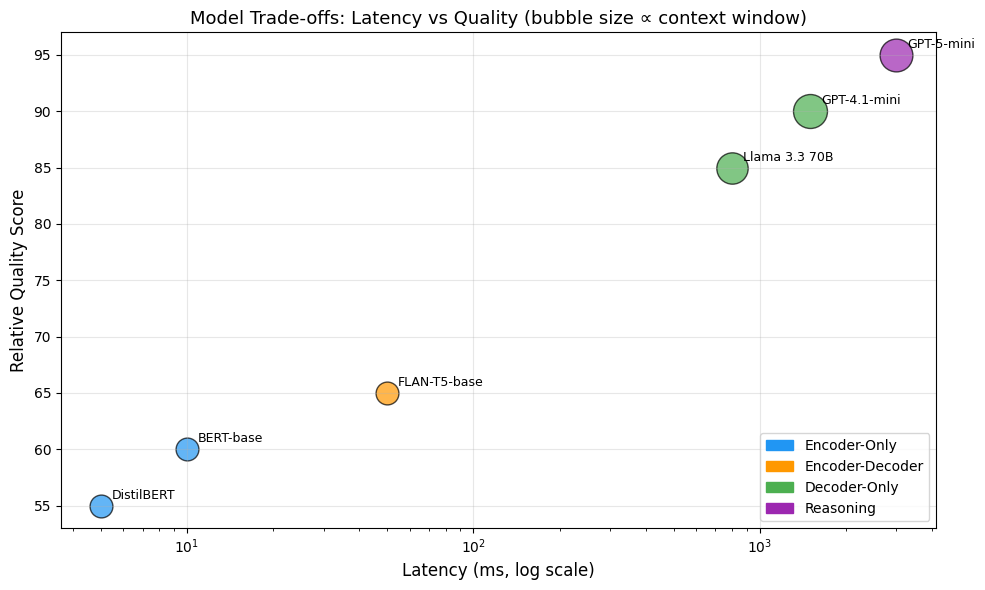

In [29]:
# Visualize the cost-quality-latency trade-off
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))

# Data: (latency_ms, relative_quality, bubble_size=context_window_log)
models = {
    "BERT-base":      {"lat": 10,   "qual": 60, "ctx": 512,     "color": "#2196F3", "arch": "Encoder-Only"},
    "DistilBERT":     {"lat": 5,    "qual": 55, "ctx": 512,     "color": "#2196F3", "arch": "Encoder-Only"},
    "FLAN-T5-base":   {"lat": 50,   "qual": 65, "ctx": 512,     "color": "#FF9800", "arch": "Enc-Dec"},
    "Llama 3.3 70B":  {"lat": 800,  "qual": 85, "ctx": 128000,  "color": "#4CAF50", "arch": "Decoder-Only"},
    "GPT-4.1-mini":   {"lat": 1500, "qual": 90, "ctx": 1000000, "color": "#4CAF50", "arch": "Decoder-Only"},
    "GPT-5-mini":     {"lat": 3000, "qual": 95, "ctx": 400000,  "color": "#9C27B0", "arch": "Reasoning"},
}

import numpy as np
for name, m in models.items():
    size = max(np.log2(m["ctx"]) * 30, 100)
    ax.scatter(m["lat"], m["qual"], s=size, c=m["color"], alpha=0.7, edgecolors="black")
    ax.annotate(name, (m["lat"], m["qual"]), fontsize=9,
                xytext=(8, 5), textcoords="offset points")

ax.set_xscale("log")
ax.set_xlabel("Latency (ms, log scale)", fontsize=12)
ax.set_ylabel("Relative Quality Score", fontsize=12)
ax.set_title("Model Trade-offs: Latency vs Quality (bubble size ∝ context window)", fontsize=13)

# Legend
patches = [
    mpatches.Patch(color="#2196F3", label="Encoder-Only"),
    mpatches.Patch(color="#FF9800", label="Encoder-Decoder"),
    mpatches.Patch(color="#4CAF50", label="Decoder-Only"),
    mpatches.Patch(color="#9C27B0", label="Reasoning"),
]
ax.legend(handles=patches, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 13. Conclusion & Key Takeaways

### What We Covered

| Section | Key Takeaway |
|---|---|
| **Tokenization** | BPE / WordPiece / SentencePiece split text differently — always use the model's own tokenizer for budget estimation |
| **Context windows** | Range from 512 (BERT) to 1M (GPT-4.1) tokens — drives chunking strategy |
| **Encoder-Only (BERT)** | Best for classification, NER, embeddings — fast, cheap, bidirectional |
| **Decoder-Only (GPT/Llama)** | Best for generation, chat, reasoning — causal attention, scales massively |
| **Encoder-Decoder (T5)** | Best for seq-to-seq (summarize, translate) — cross-attention bridges input and output |
| **Attention visualization** | Heatmaps reveal what the model focuses on — interpretability tool |
| **Architecture selection** | Match architecture to task type, volume, latency, cost — no single winner |

### Production Decision Framework
1. **Classification / extraction at scale** → fine-tuned Encoder-Only (BERT/DistilBERT).
2. **Open-ended generation / chat** → Decoder-Only API (GPT-5-mini, Llama 3.3 via Groq).
3. **Structured input → output transformation** → Encoder-Decoder (T5) for small/cheap; Decoder-Only API for higher quality.
4. **Latency-critical (< 50 ms)** → small fine-tuned encoder on your own GPU.
5. **Multi-step reasoning** → reasoning-enabled decoder (`gpt-5-mini`, Claude with extended thinking).

## 14. Stretch Exercise (Optional)
1. **Tokenizer comparison.** Tokenize a multilingual document (English + Hindi + code snippet) with BERT, GPT-4o, and Llama tokenizers; compare token counts and visualize splits.
2. **Attention head probing.** Plot multiple heads from layer 6 of BERT and identify a head that focuses on subject-verb relationships.
3. **DistilBERT swap.** Replace BERT with DistilBERT in the NER pipeline; measure latency speedup and any accuracy drop.
4. **Encoder-decoder vs decoder-only summarization.** Summarize the same RBI circular with FLAN-T5 and `gpt-4.1-mini`; rank by faithfulness using `gpt-5-mini` as judge.
5. **Context-window stress test.** Feed progressively longer documents to BERT (512), Llama 3.3 (128 K), and GPT-4.1 (1 M); track where each fails and why.



---

## Interview Preparation

The questions below mirror what client interviewers commonly ask about the topics in this lab. Use the hint to think through the answer first; use the sketch only to verify your reasoning.

---

**Q1. Encoder-only vs decoder-only vs encoder-decoder — pick the right architecture for: (a) Named-Entity Recognition, (b) free-form text generation, (c) machine translation. Justify each.**

*Hint:* Look at whether you need bidirectional understanding, autoregressive generation, or input→output transformation.

*Answer sketch:* (a) NER → encoder-only (BERT) — token-level classification needs bidirectional context. (b) Generation → decoder-only (GPT/Llama) — causal attention is built for left-to-right generation. (c) Translation → encoder-decoder (T5/MarianMT) — input is fully available before output starts; cross-attention bridges them. Modern very-large decoder-only models can do (c) too, but at higher cost.

---

**Q2. What is a context window, and how does tokenization affect how much you can fit in it?**

*Hint:* Context window is in *tokens*, not characters or words.

*Answer sketch:* The context window is the maximum number of tokens (input + output) a model can attend to in a single call. Tokenization determines tokens-per-character: a tokenizer that splits Hindi/code into many tiny pieces eats the budget faster than one trained on that distribution. Always count tokens with the *model's own* tokenizer (e.g., `tiktoken` for OpenAI, `transformers` `AutoTokenizer` for HF models) before estimating costs or fit.

---

**Q3. The same prompt costs different token counts on different models. Why?**

*Hint:* Each model has its own vocabulary and merge rules.

*Answer sketch:* Different tokenizers produce different splits. GPT-4o's `o200k_base` has ~200K merge rules optimized for code and multilingual text; Llama 3 uses a custom 128K-vocab tokenizer; BERT uses 30K WordPiece. The same English sentence may be 12 tokens in one and 18 in another. For non-English or code-heavy text the gap widens. Token-count → cost is *per model*, never universal.

---

**Q4. What is self-attention, and what does an individual attention head learn?**

*Hint:* Think queries / keys / values; heads as parallel views.

*Answer sketch:* Self-attention computes, for each token, a weighted sum over all other tokens — weights come from the dot product of that token's *query* with every other token's *key*. Different heads learn different relations: some attend to syntactic neighbors (subject↔verb), some to coreference (a pronoun↔its antecedent), some to long-range topical links. Multi-head = multiple parallel attention patterns whose outputs are concatenated.

---

**Q5. When would you NOT use a generative LLM, and pick a smaller specialized encoder model instead?**

*Hint:* Latency, cost, predictability, regulatory needs.

*Answer sketch:* High-volume classification with strict latency (e.g., real-time fraud, ad ranking, log triage) — a fine-tuned DistilBERT at ~5 ms is cheaper, faster, and more deterministic than an LLM call. Also: anywhere the output space is small and known (sentiment, intent, NER tags), or where you need on-prem inference for compliance with no per-call vendor cost.

---

**Q6. Scaling laws — what changes when you 10× the parameters vs 10× the training data?**

*Hint:* Chinchilla — they should scale together.

*Answer sketch:* Loss decreases as a power law in both, but only when scaled in proportion (Chinchilla finding: ~20 tokens per parameter). 10× parameters with the same data → diminishing returns and overfitting; 10× data with the same parameters → model is under-parameterized to absorb it. Compute-optimal is to scale them together. In practice this is why later models (Llama 3) are smaller-but-trained-on-more-data than naive scaling would suggest.

---

**Q7. Difference between greedy decoding, temperature sampling, and top-p (nucleus) sampling — when use each?**

*Hint:* Determinism vs creativity vs cutting the long tail.

*Answer sketch:* **Greedy** picks `argmax` at each step — deterministic, can get stuck in repetition. **Temperature sampling** divides logits by `T` before softmax: `T<1` sharpens (more deterministic), `T>1` flattens (more creative); samples from the full distribution. **Top-p** keeps only the smallest set of tokens whose cumulative probability ≥ p, then samples — cuts low-probability tail without hard-capping like top-k. Use greedy for factual extraction; low-temp + top-p ≈ 0.9 for production chat; high temp for brainstorming.

---

**Q8. Reading attention heatmaps — what does "early layers vs late layers" tell you, and why is averaging across heads useful?**

*Hint:* Layers learn different abstraction levels.

*Answer sketch:* Early layers tend to attend locally — adjacent tokens, syntax, surface features. Later layers attend to long-range semantic relations (e.g., "bank" ↔ "loan" ↔ "credit"). Each individual head specializes; **averaging across heads in a layer** gives a composite view of *which tokens that layer collectively focused on*, which is easier to debug than reading 12 heads separately. Useful for investigating misclassifications: if the model attended to the wrong tokens, you see it in the late-layer heatmap.
